In [ ]:
# author: Issakha Diouf
# date: 2025-02-01

In [2]:
!pip install tensorflow==2.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 41.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found

In [4]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,InputLayer, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [5]:
#Define a function to load dataset images
def recupDataset(data_dir):
    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)
    return filepaths,labels

In [6]:
#Read data and store it in dataframe
# Generate data paths with labels
bird_dir = '/kaggle/input/high-resolution-catdogbird-image-dataset-13000/bird'
cat_dir = '/kaggle/input/high-resolution-catdogbird-image-dataset-13000/cat'
dog_dir = '/kaggle/input/high-resolution-catdogbird-image-dataset-13000/dog'
filepaths = []
labels = []

recupDataset(bird_dir)
recupDataset(cat_dir)
recupDataset(dog_dir)


# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')#contains imagespaths
Lseries = pd.Series(labels, name='labels')#contains imagelabels
dataset = pd.concat([Fseries, Lseries], axis= 1)

In [7]:
dataset[:5]

,filepaths,labels
0,/kaggle/input/high-resolution-catdogbird-image...,bird
1,/kaggle/input/high-resolution-catdogbird-image...,bird
2,/kaggle/input/high-resolution-catdogbird-image...,bird
3,/kaggle/input/high-resolution-catdogbird-image...,bird
4,/kaggle/input/high-resolution-catdogbird-image...,bird


In [8]:
train_ds, tmp_ds = train_test_split(dataset, train_size=0.8, shuffle=True, random_state=123)
valid_ds, test_ds = train_test_split(tmp_ds, train_size=0.6, shuffle=True, random_state=123)

In [9]:
#Create image data generator
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Recommended : use custom function for test data batch size, else we can use normal batch size.
ts_length = len(test_ds)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

# This function which will be used in image data generator for data augmentation, it just take the image and return it again.
def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar,
                            rotation_range=40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            brightness_range=[0.4,0.6],
                            zoom_range=0.3,
                            horizontal_flip=True,
                            vertical_flip=True)

ts_gen = ImageDataGenerator(preprocessing_function= scalar,
                            rotation_range=40,
                            width_shift_range=0.2,
                            height_shift_range=0.2,
                            brightness_range=[0.4,0.6],
                            zoom_range=0.3,
                            horizontal_flip=True,
                            vertical_flip=True)

train_gen = tr_gen.flow_from_dataframe( train_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

# Note: we will use custom test_batch_size, and make shuffle= false
test_gen = ts_gen.flow_from_dataframe( test_ds, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

Found 10675 validated image filenames belonging to 3 classes.
Found 1601 validated image filenames belonging to 3 classes.
Found 1068 validated image filenames belonging to 3 classes.


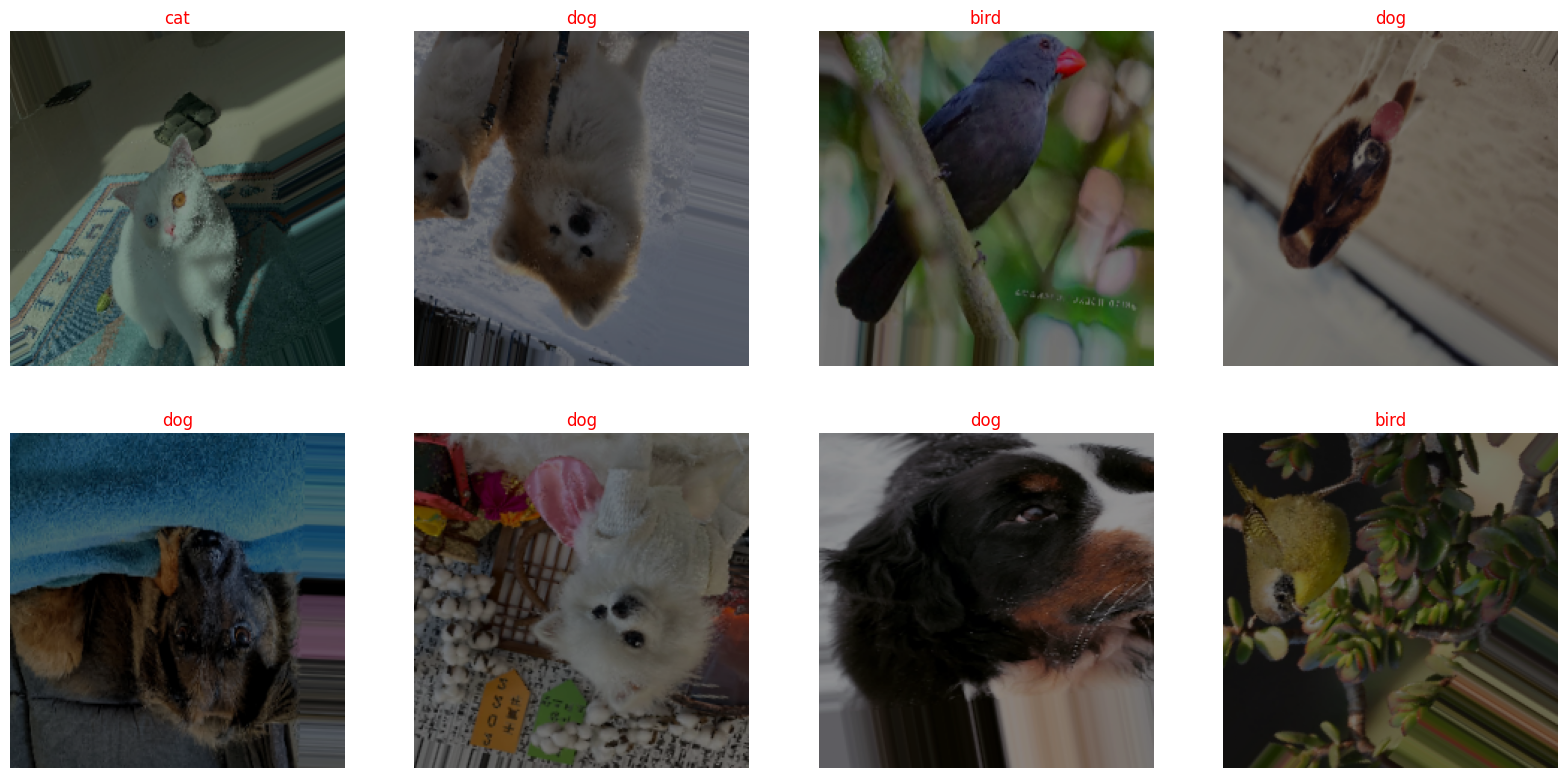

In [10]:
#Show sample from train data
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(8):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'red', fontsize= 12)
    plt.axis('off')
plt.show()

In [11]:
### Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

EfficientNetB0_model= tf.keras.applications.efficientnet.EfficientNetB0(include_top= False,
                                                                        weights= "imagenet",
                                                               input_shape= img_shape,
                                                                        pooling= 'max')
EfficientNetB0_model.trainable = True

model = Sequential([
    EfficientNetB0_model,
    Dense(132, activation= 'relu'),
    Dense(64, activation= 'relu'),
    Dense(3, activation= 'softmax')
])


#model.summary()

16705208/16705208 [==============================] - 1s 0us/step


In [12]:
#Compile the model with a loss function and an optimizer
adam = keras.optimizers.Adam(learning_rate=0.001)#optimizer
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=["accuracy"])

In [13]:
#training the model
batch_size = 16   # set batch size for training
epochs = 5   # number of all epochs in training

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, 
                    validation_steps= None, shuffle= False)

Epoch 1/5
668/668 [==============================] - 493s 685ms/step - loss: 0.4564 - accuracy: 0.8384 - val_loss: 0.3688 - val_accuracy: 0.8682
Epoch 2/5
668/668 [==============================] - 406s 607ms/step - loss: 0.3376 - accuracy: 0.8785 - val_loss: 0.3188 - val_accuracy: 0.8913
Epoch 3/5
668/668 [==============================] - 384s 575ms/step - loss: 0.2737 - accuracy: 0.8975 - val_loss: 0.2800 - val_accuracy: 0.8994
Epoch 4/5
668/668 [==============================] - 377s 565ms/step - loss: 0.2620 - accuracy: 0.9040 - val_loss: 0.2474 - val_accuracy: 0.9038
Epoch 5/5
668/668 [==============================] - 375s 561ms/step - loss: 0.2506 - accuracy: 0.9088 - val_loss: 0.2434 - val_accuracy: 0.9107


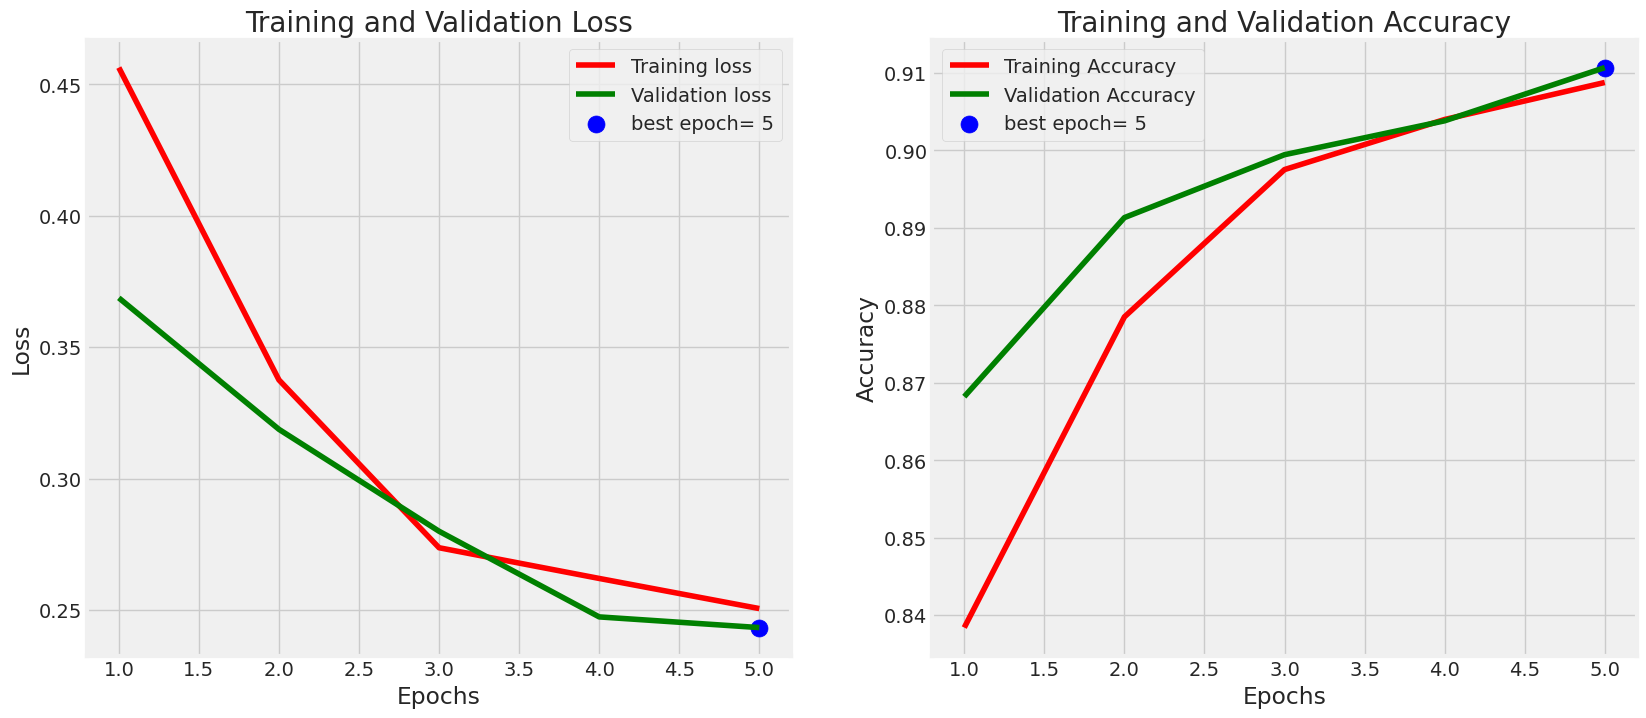

In [14]:
#Display model performances
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show()

In [15]:
ts_length = len(test_gen)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])


89/89 [==============================] - 42s 459ms/step - loss: 0.2136 - accuracy: 0.9232
Train Loss:  0.2156268060207367
Train Accuracy:  0.9213483333587646
--------------------
Validation Loss:  0.23678921163082123
Validation Accuracy:  0.9129213690757751
--------------------
Test Loss:  0.2135843187570572
Test Accuracy:  0.9232209920883179


In [16]:
#Get Predictions
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

89/89 [==============================] - 34s 369ms/step


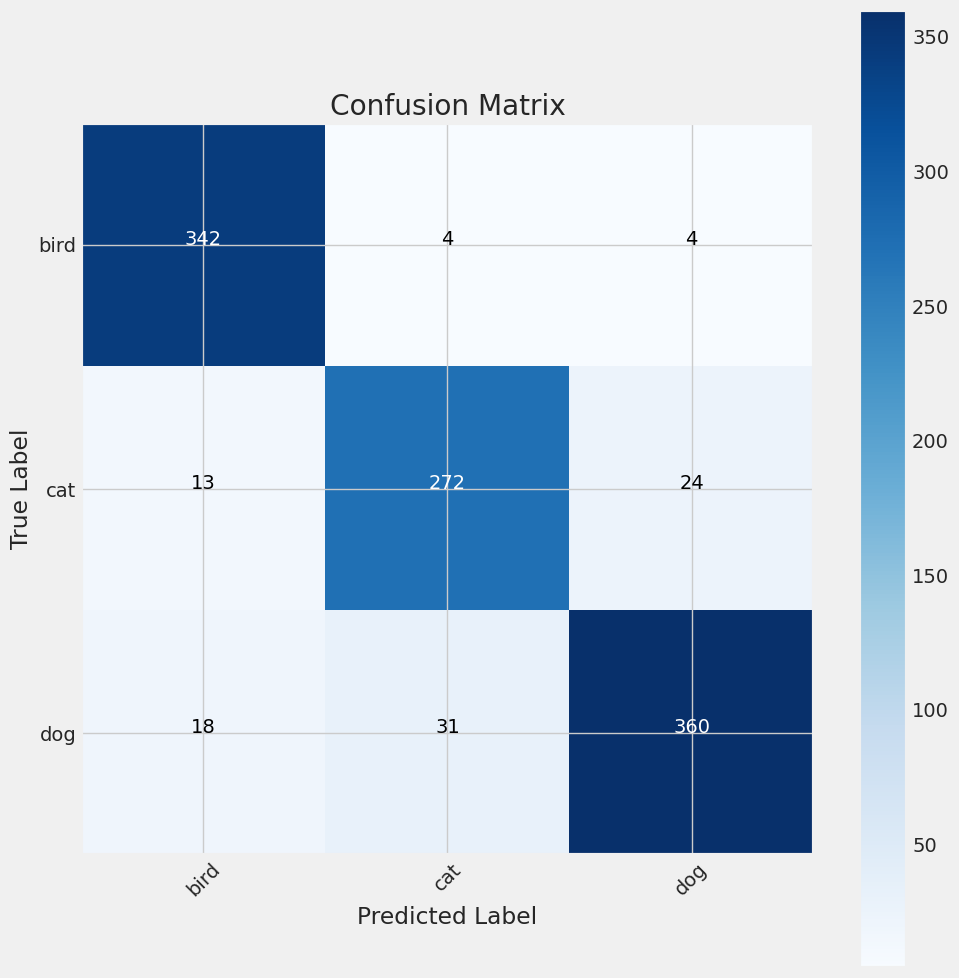

In [18]:
#
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [16]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

        bird       0.90      0.97      0.93       350
         cat       0.94      0.89      0.91       309
         dog       0.92      0.90      0.91       409

    accuracy                           0.92      1068
   macro avg       0.92      0.92      0.92      1068
weighted avg       0.92      0.92      0.92      1068



In [19]:
#---------How to save a model---------------------
!mkdir -p saved_model

model.save('saved_model/ANN_model.h5')
model.save_weights('saved_model/ANN_model_weights.h5')

In [21]:
#---------How to reuse a model already saved---------------------
from keras.models import load_model
already_trained_model = load_model('saved_model/ANN_model.h5')
#you can now evaluate this model or make prediction with it.

In [24]:
#Define a function wich loads image to predict
import keras.utils as image
def load_image(img_path, show=True):

    img = image.load_img(img_path, target_size=(224, 224))
    img_tensor = image.img_to_array(img)                    # (height, width, channels)
    img_tensor = np.expand_dims(img_tensor, axis=0)         # (1, height, width, channels), add a dimension because the model expects this shape: (batch_size, height, width, channels)
    img_tensor /= 255.                                      # imshow expects values in the range [0, 1]

    if show:
        plt.imshow(img_tensor[0])
        plt.axis('off')
        plt.show()

    return img_tensor

In [25]:
#Show classes order
classes

['bird', 'cat', 'dog']

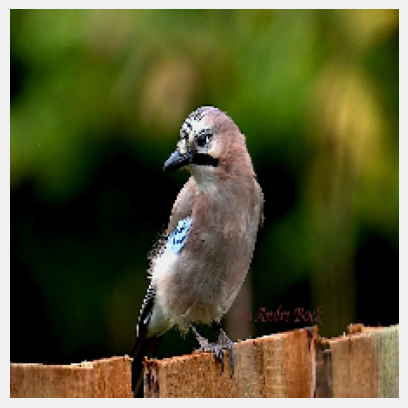

1/1 [==============================] - 0s 24ms/step
[[0.81161535 0.0336726  0.154712  ]]


In [28]:
#------Let's make prediction on new images
img_path= "/kaggle/input/high-resolution-catdogbird-image-dataset-13000/bird/bird/0.jpg"
new_image = load_image(img_path)
pred = already_trained_model.predict(new_image)

print(pred)


In [29]:
#Download the model for a further deployment
from IPython.display import FileLink
!zip -r My_Model.zip "saved_model/ANN_model.h5"
%cd /kaggle/working
FileLink('My_Model.zip')

  adding: saved_model/ANN_model.h5 (deflated 9%)
/kaggle/working


/kaggle/working/My_Model.zip